# Anomaly Detection

We use Isolation Forest to detect anomalies in time-series metrics. We'll use the MonthlyCharges feature from the Telco dataset as an example stream.


In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

churn_data_path = 'data/telco_churn.csv'

if os.path.exists(churn_data_path):
    df = pd.read_csv(churn_data_path)
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
    
    # Simulate a time series by just taking random normal users' sequential monthly charges
    normal_data = df[df['Churn'] == 'No']['MonthlyCharges'].dropna().values[:1000]
    X = normal_data.reshape(-1, 1)
    print(f'Prepared {len(X)} data points.')
else:
    print('Dataset not found. Run churn_prediction notebook first to download it!')


Prepared 1000 data points.


C:\Users\arshv\AppData\Local\Temp\ipykernel_4944\2640736648.py:12: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


## Train Isolation Forest


In [2]:
# Let's inject a few synthetic anomalies to make sure it works
np.random.seed(42)
anomalies = np.array([180, 200, 250, 10, 5]).reshape(-1, 1)
X_with_anomalies = np.vstack([X, anomalies])

# Contamination assumes roughly what % of the data are anomalies
model = IsolationForest(contamination=0.05, random_state=42, n_estimators=100)
model.fit(X_with_anomalies)

predictions = model.predict(X_with_anomalies)
anomaly_indices = np.where(predictions == -1)[0]

print(f'Model trained. Found {len(anomaly_indices)} anomalies out of {len(X_with_anomalies)} points.')


Model trained. Found 51 anomalies out of 1005 points.


## Visualize Anomalies


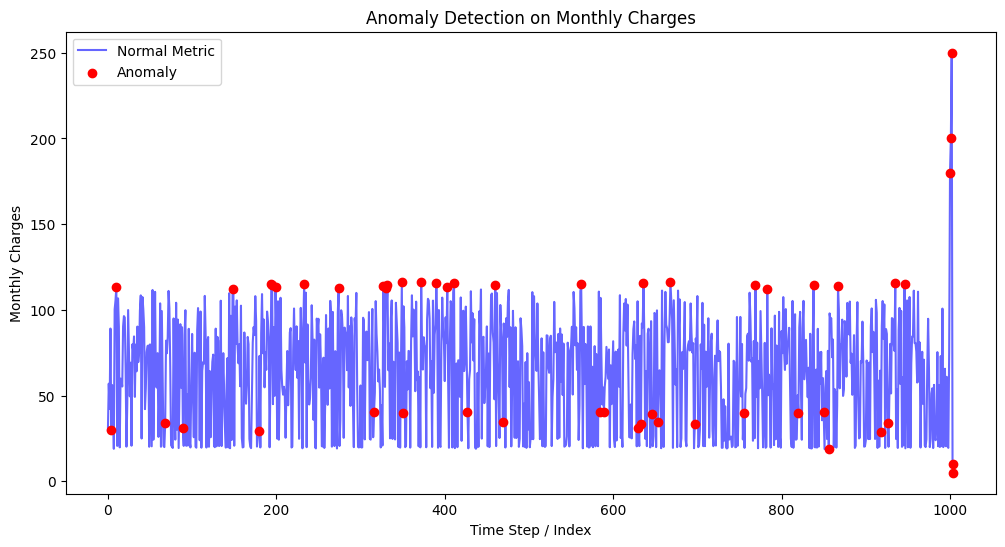

: 

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(range(len(X_with_anomalies)), X_with_anomalies, label='Normal Metric', color='blue', alpha=0.6)
plt.scatter(anomaly_indices, X_with_anomalies[anomaly_indices], color='red', label='Anomaly', zorder=5)
plt.xlabel('Time Step / Index')
plt.ylabel('Monthly Charges')
plt.title('Anomaly Detection on Monthly Charges')
plt.legend()
plt.show()
